In [1]:
!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless
!pip install opencv-python==4.10.0.84

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 16.9 MB/s eta 0:00:00


In [2]:
from pathlib import Path
print(Path.cwd())

/content


In [3]:
%cd /content

!git clone https://github.com/Aishwarya-93/Deepfake-Detection-KYC.git

%cd Deepfake-Detection-KYC

/content
Cloning into 'Deepfake-Detection-KYC'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (114/114), done.
remote: Total 144 (delta 71), reused 83 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (144/144), 2.90 MiB | 8.25 MiB/s, done.
Resolving deltas: 100% (71/71), done.
/content/Deepfake-Detection-KYC


In [4]:
!kaggle datasets download -d xdxd003/ff-c23
!unzip -q ff-c23.zip -d data/raw/

Dataset URL: https://www.kaggle.com/datasets/xdxd003/ff-c23
License(s): other
100% 16.7G/16.7G [03:23<00:00, 88.1MB/s]



In [7]:
import cv2

print(cv2.__version__)
print(hasattr(cv2, "CascadeClassifier"))

4.10.0
True


In [14]:
from pathlib import Path

from src.preprocessing import video_loader
from src.preprocessing import frame_extractor
from src.preprocessing import face_detector
from src.preprocessing import image_preprocessing

In [15]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

FRAME_DIR = PROJECT_ROOT / "outputs" / "frames"
FACE_DIR = PROJECT_ROOT / "outputs" / "faces"
PROCESSED_DIR = PROJECT_ROOT / "outputs" / "processed_faces"

FRAME_DIR.mkdir(parents=True, exist_ok=True)
FACE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [16]:
def process_video(video_path):

    import cv2

    print("Loading face detector...")

    detector = face_detector.load_face_detector()

    print("Extracting frames...")

    frame_extractor.extract_frames(
        video_path,
        FRAME_DIR,
        interval=10
    )

    frame_files = sorted(FRAME_DIR.glob("*.jpg"))

    print(f"Frames found: {len(frame_files)}")

    total_faces = 0

    for frame_file in frame_files:

        image = cv2.imread(str(frame_file))

        if image is None:
            continue

        faces = face_detector.detect_faces(
            image,
            detector
        )

        cropped_faces = face_detector.crop_faces(
            image,
            faces
        )

        for face in cropped_faces:

            try:

                processed_face = image_preprocessing.resize_image(
                    face,
                    (224, 224)
                )

                processed_face = (
                    image_preprocessing.normalize_image(
                        processed_face
                    )
                )

                save_path = (
                    PROCESSED_DIR
                    / f"face_{total_faces:05d}.jpg"
                )

                cv2.imwrite(
                    str(save_path),
                    (processed_face * 255).astype("uint8")
                )

                total_faces += 1

            except Exception as e:

                print(
                    f"Error processing face: {e}"
                )

    print(
        f"Pipeline complete. Faces processed: {total_faces}"
    )

    return total_faces

In [17]:
from pathlib import Path

DATASET = Path(
    "data/raw/FaceForensics++_C23"
)

videos = list(
    (DATASET / "original").glob("*.mp4")
)

print("Videos found:", len(videos))

video = videos[0]

print(video)

Videos found: 1000
data/raw/FaceForensics++_C23/original/077.mp4


In [18]:
process_video(video)

Loading face detector...
Extracting frames...
Frames found: 62
Pipeline complete. Faces processed: 103


103

In [19]:
print("Frames:",
      len(list(FRAME_DIR.glob("*.jpg"))))

print("Processed Faces:",
      len(list(PROCESSED_DIR.glob("*.jpg"))))

Frames: 62
Processed Faces: 103


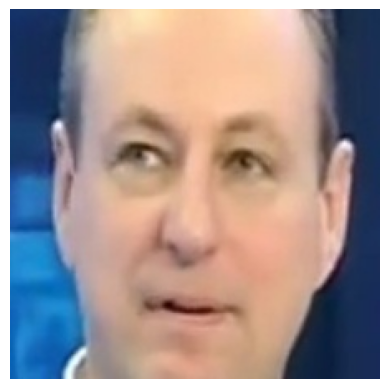

In [20]:
import cv2
import matplotlib.pyplot as plt

sample = list(
    PROCESSED_DIR.glob("*.jpg")
)[0]

img = cv2.imread(str(sample))

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.imshow(img)
plt.axis("off")
plt.show()

In [21]:
print("Frames:",
      len(list(FRAME_DIR.glob("*.jpg"))))

print("Processed Faces:",
      len(list(PROCESSED_DIR.glob("*.jpg"))))

Frames: 62
Processed Faces: 103


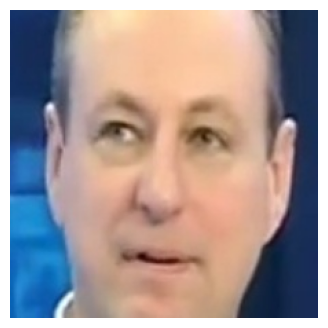

In [22]:
import cv2
import matplotlib.pyplot as plt

sample = list(PROCESSED_DIR.glob("*.jpg"))[0]

img = cv2.imread(str(sample))

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.show()